Sunpy uses a took called Fido to search and download solar data from various sources - GOES/XRS included. 

In [1]:
import sunpy
from sunpy.net import Fido, attrs as a
import matplotlib.pyplot as plt
import sunpy.timeseries as ts

#look for data on august 20th, 2026
time = a.Time("2026-08-20 12:00", "2026-08-20 20:00")
print(Fido.search(time, a.Instrument("XRS")))

Results from 1 Provider:

2 Results from the XRSClient:
Source: <8: https://umbra.nascom.nasa.gov/goes/fits 
8-15: https://www.ncei.noaa.gov/data/goes-space-environment-monitor/access/science/ 
16-17: https://data.ngdc.noaa.gov/platforms/solar-space-observing-satellites/goes/

       Start Time               End Time        Instrument  Physobs   Source Provider Resolution SatelliteNumber
----------------------- ----------------------- ---------- ---------- ------ -------- ---------- ---------------
2026-08-20 00:00:00.000 2026-08-20 23:59:59.999        XRS irradiance   GOES     NOAA      flx1s              18
2026-08-20 00:00:00.000 2026-08-20 23:59:59.999        XRS irradiance   GOES     NOAA      avg1m              18




There is only one satellite available. The two entries are due to the two different time resolutions. flx1s is a 1-second resolution and avg1m is 1-minute averages. For now will use avg1m because it's a smaller file, but can change this later on.

Files Downloaded:   0%|          | 0/1 [00:00<?, ?file/s]

sci_xrsf-l2-avg1m_g18_d20260820_v2-2-1.nc:   0%|          | 0.00/301k [00:00<?, ?B/s]

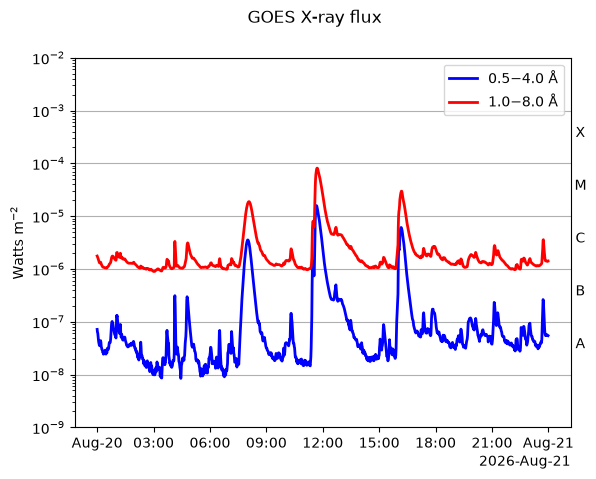

In [3]:
result = Fido.search(time, a.Instrument("XRS"))
files = Fido.fetch(result[0,1])

goes = ts.TimeSeries(files, concatenate=True)
goes.peek()

Here I can see the target flare and potential separate, earlier flares at around 8 and 12 UTC.

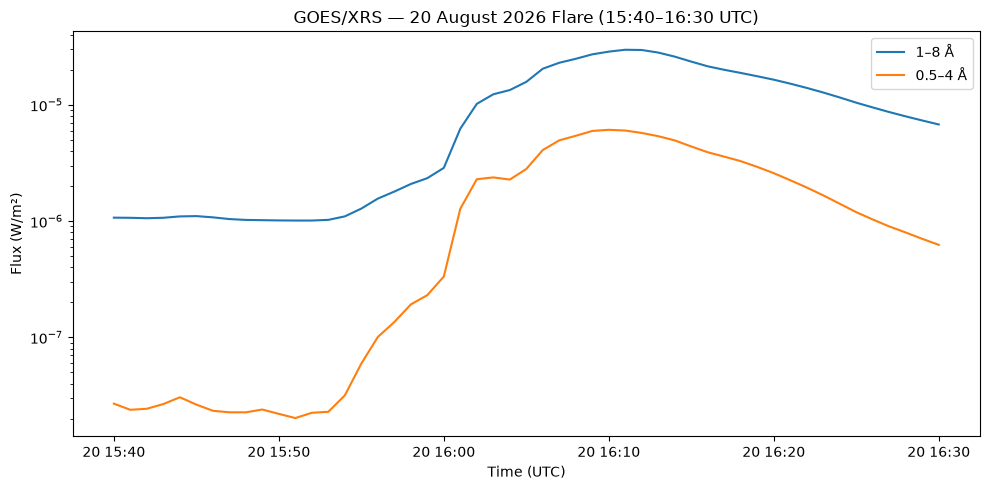

In [10]:
df = goes.to_dataframe()
flare_window = df.loc["2026-08-20 15:40":"2026-08-20 16:30"]

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(flare_window.index, flare_window['xrsb'], label='1–8 Å')
ax.plot(flare_window.index, flare_window['xrsa'], label='0.5–4 Å')

ax.set_yscale('log')
ax.set_xlabel('Time (UTC)')
ax.set_ylabel('Flux (W/m²)')
ax.set_title('GOES/XRS — 20 August 2026 Flare (15:40–16:30 UTC)')
ax.legend()

plt.tight_layout()
plt.savefig('../figures/goes_aug20.png')
plt.show()